In [ ]:
%pip install pandas numpy matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

In [6]:
df = pd.read_csv("demand_forecasting.csv")

In [7]:
df.head(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
5,2022-01-01,S001,P0006,Toys,North,209,60,0,35.53,0,Snowy,0,40.01,Winter,0,55
6,2022-01-01,S001,P0007,Groceries,North,118,81,335,23.27,5,Snowy,0,24.78,Winter,0,94
7,2022-01-01,S001,P0008,Electronics,North,244,42,0,37.79,5,Snowy,0,44.85,Winter,0,61
8,2022-01-01,S001,P0009,Clothing,North,115,88,139,94.20,5,Snowy,0,108.70,Winter,0,129
9,2022-01-01,S001,P0010,Furniture,North,192,70,300,113.35,10,Snowy,0,129.98,Winter,0,69


In [8]:
df["Epidemic"].value_counts()

Epidemic
0    60800
1    15200
Name: count, dtype: int64

In [9]:
df.dtypes

Date                      str
Store ID                  str
Product ID                str
Category                  str
Region                    str
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition         str
Promotion               int64
Competitor Pricing    float64
Seasonality               str
Epidemic                int64
Demand                  int64
dtype: object

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

In [11]:
df.dtypes

Date                  datetime64[us]
Store ID                         str
Product ID                       str
Category                         str
Region                           str
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition                str
Promotion                      int64
Competitor Pricing           float64
Seasonality                      str
Epidemic                       int64
Demand                         int64
dtype: object

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[us]
 1   Store ID            76000 non-null  str           
 2   Product ID          76000 non-null  str           
 3   Category            76000 non-null  str           
 4   Region              76000 non-null  str           
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  str           
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  str           
 14  E

In [13]:
df.isna()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
75996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
75997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
75998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
df.isna().sum()


Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [15]:
df.isna().sum().sum() 
#general sum

np.int64(0)

In [16]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
75995    False
75996    False
75997    False
75998    False
75999    False
Length: 76000, dtype: bool

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,2023-01-15 12:00:00,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
min,2022-01-01 00:00:00,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,2022-07-09 18:00:00,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,2023-01-15 12:00:00,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,2023-07-24 06:00:00,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2024-01-30 00:00:00,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000
std,NaN,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801


In [19]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [ ]:
df.describe(include="str")

In [ ]:
df.describe(include="str").T

In [22]:
df["Date"].dt.year

0        2022
1        2022
2        2022
3        2022
4        2022
         ... 
75995    2024
75996    2024
75997    2024
75998    2024
75999    2024
Name: Date, Length: 76000, dtype: int32

In [23]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
#Creates a new column for the year and month extracted from the Date column

In [24]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64,2024,1
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137,2024,1
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68,2024,1
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84,2024,1


In [25]:
df["Day"] = df["Date"].dt.day

In [26]:
df["Weekday"] = df["Date"].dt.day_name()
#Creates a new column for the weekday extracted from the Date column example, Monday, Tuesday, etc.

In [27]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64,2024,1,30,Tuesday
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137,2024,1,30,Tuesday
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68,2024,1,30,Tuesday
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84,2024,1,30,Tuesday


In [28]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'Year', 'Month', 'Day', 'Weekday'],
      dtype='str')

In [29]:
df["Discounted Price"] = df["Price"] * (1 - df["Discount"] / 100)

In [30]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,0,85.73,Winter,0,115,2022,1,1,Saturday,69.084
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,1,92.02,Winter,0,229,2022,1,1,Saturday,68.136
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,1,60.08,Winter,0,157,2022,1,1,Saturday,56.646
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,0,85.19,Winter,0,52,2022,1,1,Saturday,78.867
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,0,51.63,Winter,0,59,2022,1,1,Saturday,54.410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,0,32.23,Winter,0,64,2024,1,30,Tuesday,28.310
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,0,40.73,Winter,0,137,2024,1,30,Tuesday,40.774
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,0,19.41,Winter,0,68,2024,1,30,Tuesday,16.029
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,0,143.71,Winter,0,84,2024,1,30,Tuesday,151.720


In [31]:
df["Sell Through Rate"] = df["Units Sold"] / df["Inventory Level"].replace(0, np.nan)
# Rows with 0 inventory have no meaningful sell-through rate, so they become NaN instead of dividing by zero

In [32]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price,Sell Through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,32.23,Winter,0,64,2024,1,30,Tuesday,28.310,0.270386
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,40.73,Winter,0,137,2024,1,30,Tuesday,40.774,0.839416
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,19.41,Winter,0,68,2024,1,30,Tuesday,16.029,0.223350
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,143.71,Winter,0,84,2024,1,30,Tuesday,151.720,0.464000


In [33]:
df["Sell Through Rate"].describe()

count    75594.000000
mean         0.437580
std          0.298007
min          0.003150
25%          0.190807
50%          0.350475
75%          0.642276
max          1.000000
Name: Sell Through Rate, dtype: float64

In [34]:
df.groupby("Category")["Demand"].agg(["mean", "sum", "std"]).sort_values(by = "sum", ascending = False)

,mean,sum,std
Category,,,
Groceries,120.976447,3677684,48.362730
Clothing,112.619737,1369456,41.022968
Furniture,73.581140,1006590,32.336141
Toys,92.606955,985338,46.170390
Electronics,97.482018,889036,40.557859


In [35]:
df.groupby("Category")["Demand"].agg(["mean", "sum", "std"]).sort_values("sum", ascending = False).reset_index()

,Category,mean,sum,std
0,Groceries,120.976447,3677684,48.362730
1,Clothing,112.619737,1369456,41.022968
2,Furniture,73.581140,1006590,32.336141
3,Toys,92.606955,985338,46.170390
4,Electronics,97.482018,889036,40.557859


In [36]:
df.groupby(["Region", "Seasonality"])["Demand"].agg(["mean", "sum", "std"]).sort_values("sum", ascending = False).reset_index()

,Region,Seasonality,mean,sum,std
0,North,Winter,102.017738,856949,46.699619
1,North,Summer,112.843750,830530,52.918188
2,North,Autumn,103.065797,750319,42.156903
3,North,Spring,97.399457,716860,47.346803
4,South,Winter,107.733095,452479,44.815400
5,East,Winter,104.273571,437949,45.885142
6,East,Summer,115.388315,424629,52.635474
7,West,Winter,100.988810,424153,46.445005
8,South,Summer,115.089946,423531,50.239100
9,West,Summer,108.111141,397849,50.567563


In [37]:
df.groupby(["Region", "Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [38]:
df.groupby("Promotion")["Demand"].mean()
#Promotion is 1 and 0 is without a promotion 

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64

In [39]:
pd.pivot_table(df, values="Demand", index="Month", columns = "Category", aggfunc="mean")

#Transpose flips an entire table so the rows become columns and vice versa
    #What it does: Swivels the entire dataset 90 degrees, turning every row into a column and every column into a row
    #Data Structure: Keeps the exact same data and cells intact without performing any calculations or aggregations
    #When to use: Use it when you need to change the sideways or vertical orientation of a whole table.
#Pivot table summarizes and reorganizes specific data values into new categories and headers
    #What it does: Takes specific row values and converts them into new column headers while grouping and summarizing information
    #Data Structure: Aggregates data (using sums, averages, or counts) and often reduces a massive list of raw records into a compact summary report.
    #When to use: Use it when you want to analyze metrics, group categories, and build flexible reports from raw data. 

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


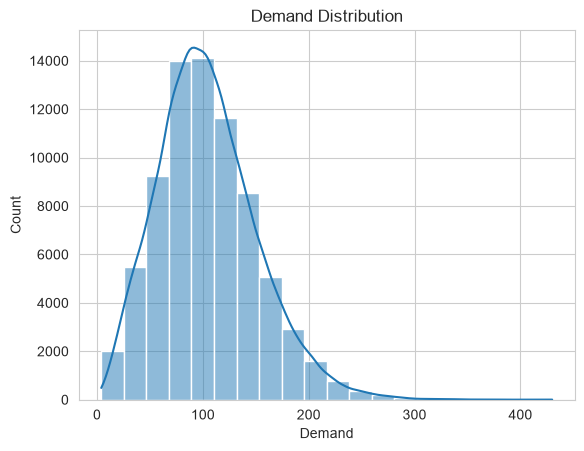

In [40]:
sns.histplot(df["Demand"], bins = 20, kde = True)
#the kde true in sns adds a smooth, continuous probability density curve on top of the histogram bars
plt.title("Demand Distribution")
plt.show()

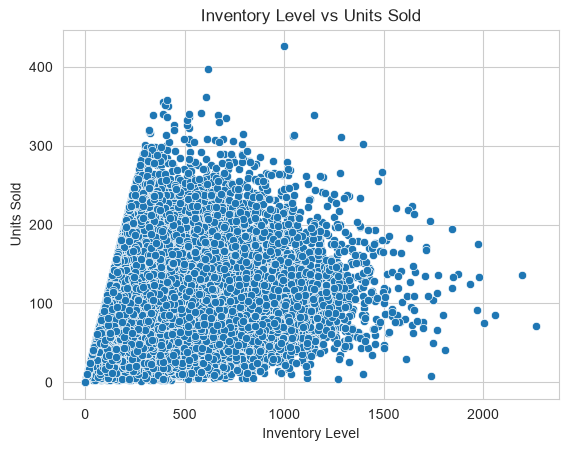

In [41]:
sns.scatterplot(data=df, x="Inventory Level", y = "Units Sold")
plt.title("Inventory Level vs Units Sold")
plt.show()

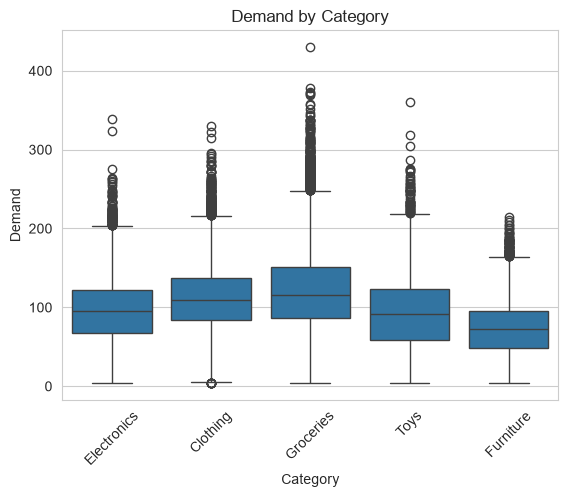

In [42]:
sns.boxplot(data = df, x= "Category", y = "Demand")  
plt.xticks(rotation = 45)
plt.title("Demand by Category")
plt.show()

#The 45 degree rotation makes the category labels more readable by slanting it at the bottom/ (example: Electronics, Clothing.... is 45 degrees)

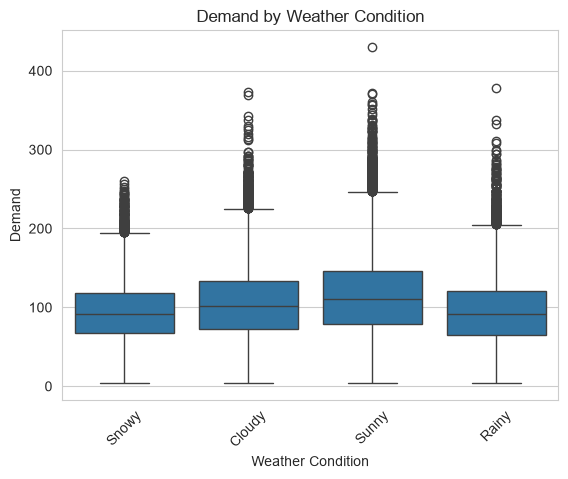

In [43]:
sns.boxplot(data = df, x = "Weather Condition", y = "Demand")
plt.xticks(rotation = 45)
plt.title("Demand by Weather Condition")
plt.show()

In [44]:
monthly_demand = df.groupby("Month")["Demand"].mean()

In [45]:
monthly_demand

Month
1     106.040000
2      92.882500
3     113.613871
4      92.816667
5      86.521129
6     117.346000
7     101.561613
8     119.803387
9     107.431500
10     95.557258
11    107.542333
12    109.003226
Name: Demand, dtype: float64

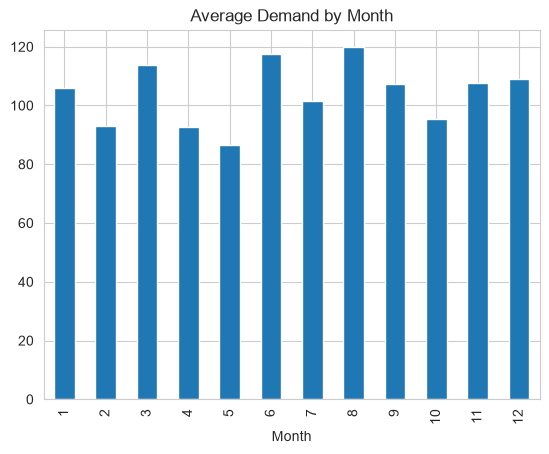

In [46]:
monthly_demand.plot(kind = "bar")
plt.title("Average Demand by Month")
plt.show()

In [47]:
#overall demand trend
daily_demand = df.groupby("Date")["Demand"].sum()

In [48]:
daily_demand

Date
2022-01-01    10060
2022-01-02    10814
2022-01-03    11317
2022-01-04    11469
2022-01-05    11724
              ...  
2024-01-26    11182
2024-01-27    11540
2024-01-28    11440
2024-01-29    10268
2024-01-30     9657
Name: Demand, Length: 760, dtype: int64

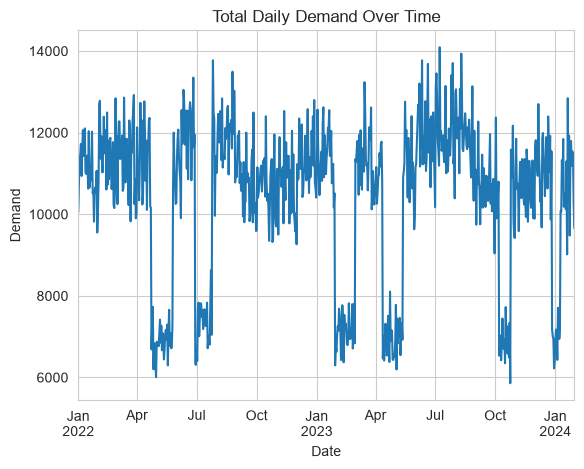

In [49]:
daily_demand.plot()
plt.title("Total Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

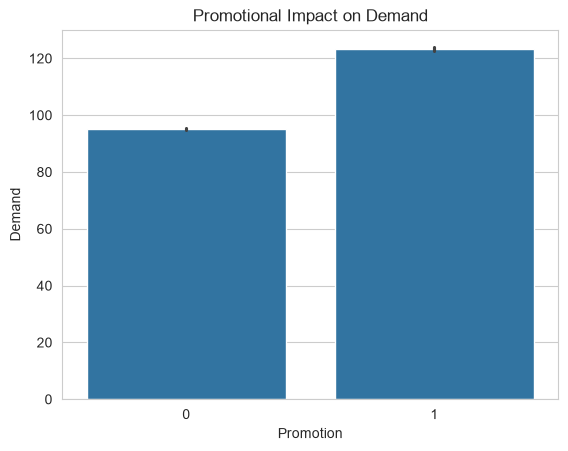

In [50]:
#check promotional impact
sns.barplot(data = df, x = "Promotion", y = "Demand")
plt.title("Promotional Impact on Demand")
plt.show()

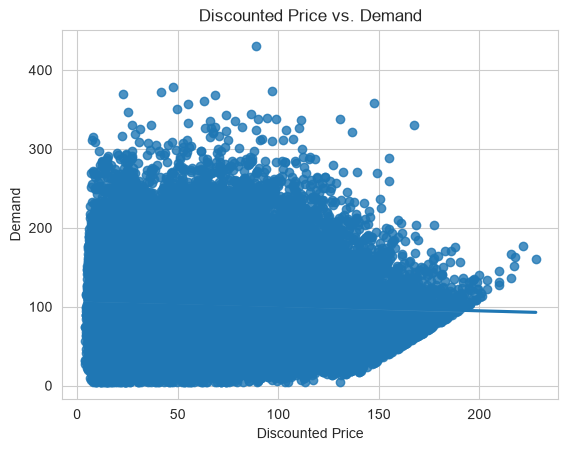

In [51]:
sns.regplot(data = df, x = "Discounted Price", y = "Demand")
plt.title("Discounted Price vs. Demand")
plt.show()

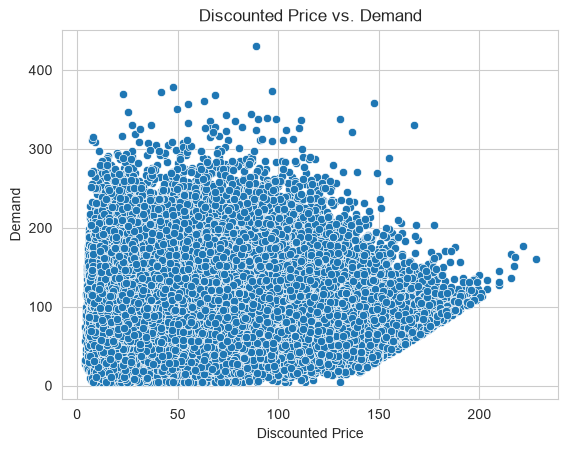

In [52]:
sns.scatterplot(data = df, x = "Discounted Price", y = "Demand")
plt.title("Discounted Price vs. Demand")
plt.show()

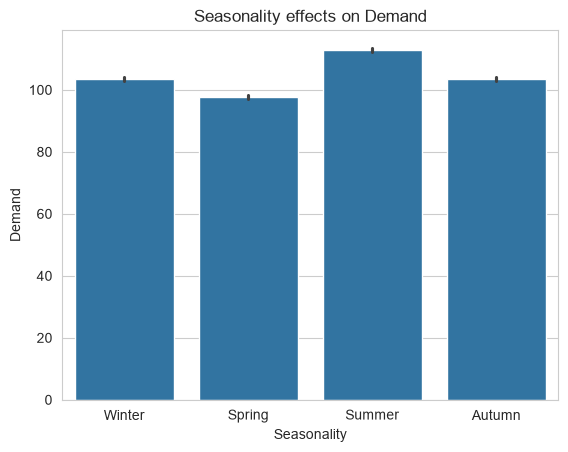

In [53]:
sns.barplot(data = df, x = "Seasonality", y = "Demand")
plt.title("Seasonality effects on Demand")
plt.show()

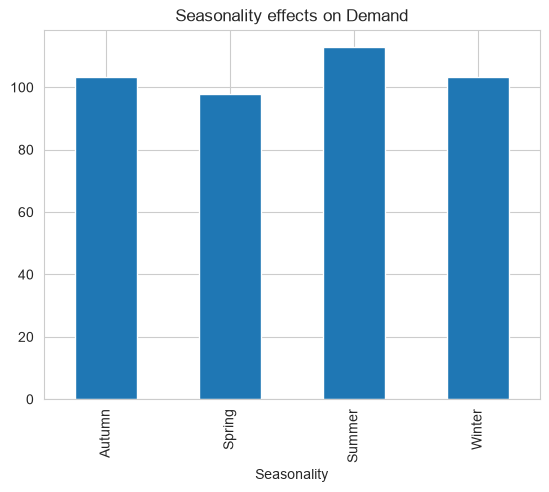

In [54]:
df.groupby("Seasonality")["Demand"].mean().plot(kind = "bar", title = "Seasonality effects on Demand")
plt.show()

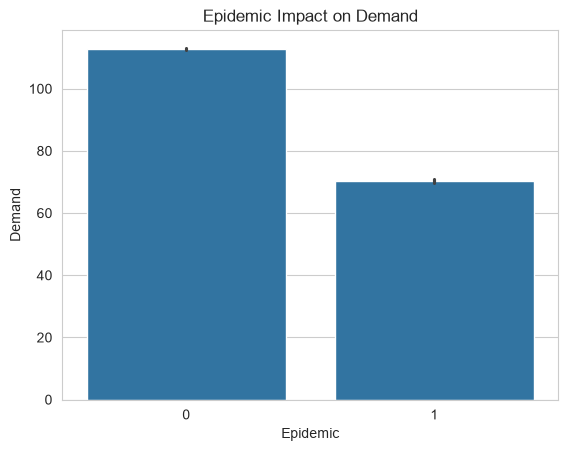

In [55]:
sns.barplot(data = df, x = "Epidemic", y = "Demand")
plt.title("Epidemic Impact on Demand")
plt.show()

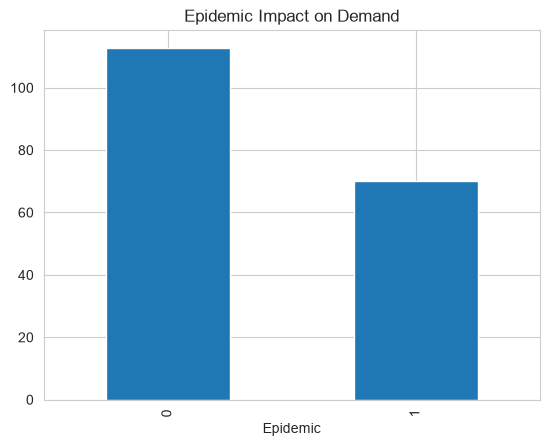

In [56]:
df.groupby("Epidemic")["Demand"].mean().plot(kind = "bar", title = "Epidemic Impact on Demand")
plt.show()

In [57]:
df.to_csv("2_preprocessed_demand_forecasting.csv", index=False) 